<a href="https://colab.research.google.com/github/Milo443/Deeplearning/blob/main/MLP_sklearn_Flattenning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importar librerias MPLclasifier**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# 1. Cargar el archivo CSV
df = pd.read_csv('/content/DataFrame_Flattenning (1).csv')

# 2. Separar características (X) y etiquetas (y)
# Optamos por usar .iloc para evitar errores si la columna no se llama exactamente 'label'
# Asumimos que la etiqueta de clase es la ÚLTIMA columna del CSV
X = df.iloc[:, :-1].values  # Todas las columnas excepto la última (las 1200 características)
y = df.iloc[:, -1].values   # Únicamente la última columna (las etiquetas)

print(f"Dataset cargado correctamente. Dimensiones de X: {X.shape}")

# 3. División y Escalado (Añadimos stratify para mantener balance de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Configuración y entrenamiento del Modelo MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(400,), #paso de capas de manera gradual mejora la precision
    activation='logistic',   #{‘identity’, ‘logistic’, ‘tanh’, ‘relu’}
    solver='adam', #{‘lbfgs’, ‘sgd’, ‘adam’}, default=’adam’
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    power_t=0.5,
    max_iter=500,            # Aumentado para asegurar convergencia
    shuffle=True,
    random_state=42,         # Cambiado de None a 42 para reproducibilidad
    tol=0.0001,
    verbose=True,            # Cambiado a True para ver el progreso de la pérdida (loss)
    warm_start=False,
    momentum=0.9,
    nesterovs_momentum=True,
    early_stopping=False,
    validation_fraction=0.1, #aseguramos el 10% de validacion
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    n_iter_no_change=10,
    max_fun=15000
)

print("\nIniciando entrenamiento del Perceptrón Multicapa...")
mlp.fit(X_train_scaled, y_train)

# 5. Evaluación de resultados
y_pred = mlp.predict(X_test_scaled)
print(f"\nPrecisión General (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación Metriza:")
print(classification_report(y_test, y_pred))


Dataset cargado correctamente. Dimensiones de X: (6480, 1200)

Iniciando entrenamiento del Perceptrón Multicapa...
Iteration 1, loss = 2.00885638
Iteration 2, loss = 1.80195333
Iteration 3, loss = 1.70423365
Iteration 4, loss = 1.64812774
Iteration 5, loss = 1.59772128
Iteration 6, loss = 1.54126491
Iteration 7, loss = 1.49365540
Iteration 8, loss = 1.44087961
Iteration 9, loss = 1.40276899
Iteration 10, loss = 1.34900724
Iteration 11, loss = 1.30369824
Iteration 12, loss = 1.25394768
Iteration 13, loss = 1.20153305
Iteration 14, loss = 1.16065040
Iteration 15, loss = 1.11478545
Iteration 16, loss = 1.06762291
Iteration 17, loss = 1.01842238
Iteration 18, loss = 0.97290220
Iteration 19, loss = 0.92530117
Iteration 20, loss = 0.87960995
Iteration 21, loss = 0.83387217
Iteration 22, loss = 0.79284925
Iteration 23, loss = 0.74853680
Iteration 24, loss = 0.70475533
Iteration 25, loss = 0.66543170
Iteration 26, loss = 0.62722752
Iteration 27, loss = 0.58929728
Iteration 28, loss = 0.5606251

### Experimentación con diferentes hiperparámetros

Vamos a experimentar con diferentes configuraciones de `hidden_layer_sizes`, `activation` y `solver` para encontrar la combinación que ofrece la mejor precisión.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder # Added import

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train, and transform y_test
# This converts string labels to numerical representations
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Definir el espacio de hiperparámetros a explorar
hidden_layer_sizes_options = [(50,), (100,), (200,), (400,), (100, 50), (500, 200), (200, 100, 50)] # Ejemplos con más capas
activation_options = ['logistic', 'tanh', 'relu','identity']
solver_options = ['adam', 'sgd','lbfgs']

results = []

print("Iniciando experimentación con diferentes configuraciones...")

for hls in hidden_layer_sizes_options:
    for activation_func in activation_options:
        for solver_type in solver_options:
            print(f"\nEntrenando con: hidden_layer_sizes={hls}, activation={activation_func}, solver={solver_type}")

            # Crear y entrenar el modelo MLP
            mlp_exp = MLPClassifier(
                hidden_layer_sizes=hls,
                activation=activation_func,
                solver=solver_type,
                max_iter=300, # Reducir max_iter para una experimentación más rápida
                random_state=42,
                early_stopping=True, # Habilitar early stopping para evitar sobreajuste y acelerar entrenamiento
                validation_fraction=0.1,
                n_iter_no_change=10,
                verbose=False # Desactivar verbose para no saturar la salida
            )

            # Use the encoded labels for fitting the model
            mlp_exp.fit(X_train_scaled, y_train_encoded)

            # Realizar predicciones y evaluar
            y_pred_exp = mlp_exp.predict(X_test_scaled)
            # Use the encoded labels for accuracy calculation
            accuracy = accuracy_score(y_test_encoded, y_pred_exp)

            print(f"  Precisión: {accuracy:.4f}")
            results.append({
                'hidden_layer_sizes': str(hls),
                'activation': activation_func,
                'solver': solver_type,
                'accuracy': accuracy
            })

print("\nExperimentación completada.")

Iniciando experimentación con diferentes configuraciones...

Entrenando con: hidden_layer_sizes=(50,), activation=logistic, solver=adam
  Precisión: 0.4005

Entrenando con: hidden_layer_sizes=(50,), activation=logistic, solver=sgd
  Precisión: 0.2407

Entrenando con: hidden_layer_sizes=(50,), activation=logistic, solver=lbfgs


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


  Precisión: 0.3441

Entrenando con: hidden_layer_sizes=(50,), activation=tanh, solver=adam
  Precisión: 0.3758

Entrenando con: hidden_layer_sizes=(50,), activation=tanh, solver=sgd
  Precisión: 0.3634

Entrenando con: hidden_layer_sizes=(50,), activation=tanh, solver=lbfgs
  Precisión: 0.3017

Entrenando con: hidden_layer_sizes=(50,), activation=relu, solver=adam
  Precisión: 0.3735

Entrenando con: hidden_layer_sizes=(50,), activation=relu, solver=sgd
  Precisión: 0.3619

Entrenando con: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs
  Precisión: 0.3681

Entrenando con: hidden_layer_sizes=(50,), activation=identity, solver=adam
  Precisión: 0.3519

Entrenando con: hidden_layer_sizes=(50,), activation=identity, solver=sgd
  Precisión: 0.3665

Entrenando con: hidden_layer_sizes=(50,), activation=identity, solver=lbfgs


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


  Precisión: 0.2924

Entrenando con: hidden_layer_sizes=(100,), activation=logistic, solver=adam
  Precisión: 0.4298

Entrenando con: hidden_layer_sizes=(100,), activation=logistic, solver=sgd
  Precisión: 0.3040

Entrenando con: hidden_layer_sizes=(100,), activation=logistic, solver=lbfgs
  Precisión: 0.3503

Entrenando con: hidden_layer_sizes=(100,), activation=tanh, solver=adam
  Precisión: 0.3935

Entrenando con: hidden_layer_sizes=(100,), activation=tanh, solver=sgd
  Precisión: 0.3966

Entrenando con: hidden_layer_sizes=(100,), activation=tanh, solver=lbfgs
  Precisión: 0.3488

Entrenando con: hidden_layer_sizes=(100,), activation=relu, solver=adam
  Precisión: 0.4082

Entrenando con: hidden_layer_sizes=(100,), activation=relu, solver=sgd
  Precisión: 0.3974

Entrenando con: hidden_layer_sizes=(100,), activation=relu, solver=lbfgs
  Precisión: 0.3920

Entrenando con: hidden_layer_sizes=(100,), activation=identity, solver=adam
  Precisión: 0.3565

Entrenando con: hidden_layer_size

...

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


  Precisión: 0.2955

Entrenando con: hidden_layer_sizes=(500, 200), activation=logistic, solver=adam
  Precisión: 0.4236

Entrenando con: hidden_layer_sizes=(500, 200), activation=logistic, solver=sgd
  Precisión: 0.2276

Entrenando con: hidden_layer_sizes=(500, 200), activation=logistic, solver=lbfgs
  Precisión: 0.4012

Entrenando con: hidden_layer_sizes=(500, 200), activation=tanh, solver=adam
  Precisión: 0.4275

Entrenando con: hidden_layer_sizes=(500, 200), activation=tanh, solver=sgd
  Precisión: 0.3796

Entrenando con: hidden_layer_sizes=(500, 200), activation=tanh, solver=lbfgs
  Precisión: 0.4066

Entrenando con: hidden_layer_sizes=(500, 200), activation=relu, solver=adam
  Precisión: 0.4506

Entrenando con: hidden_layer_sizes=(500, 200), activation=relu, solver=sgd
  Precisión: 0.3873

Entrenando con: hidden_layer_sizes=(500, 200), activation=relu, solver=lbfgs
  Precisión: 0.4383

Entrenando con: hidden_layer_sizes=(500, 200), activation=identity, solver=adam
  Precisión: 0

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


  Precisión: 0.2978

Entrenando con: hidden_layer_sizes=(200, 100, 50), activation=logistic, solver=adam
  Precisión: 0.3549

Entrenando con: hidden_layer_sizes=(200, 100, 50), activation=logistic, solver=sgd
  Precisión: 0.1304

Entrenando con: hidden_layer_sizes=(200, 100, 50), activation=logistic, solver=lbfgs
  Precisión: 0.3032

Entrenando con: hidden_layer_sizes=(200, 100, 50), activation=tanh, solver=adam
  Precisión: 0.3974

Entrenando con: hidden_layer_sizes=(200, 100, 50), activation=tanh, solver=sgd
  Precisión: 0.3843

Entrenando con: hidden_layer_sizes=(200, 100, 50), activation=tanh, solver=lbfgs
  Precisión: 0.3742

Entrenando con: hidden_layer_sizes=(200, 100, 50), activation=relu, solver=adam
  Precisión: 0.4444

Entrenando con: hidden_layer_sizes=(200, 100, 50), activation=relu, solver=sgd
  Precisión: 0.4020

Entrenando con: hidden_layer_sizes=(200, 100, 50), activation=relu, solver=lbfgs
  Precisión: 0.4228

Entrenando con: hidden_layer_sizes=(200, 100, 50), activat

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


### Visualización de los resultados de la precisión

Ahora, vamos a crear una gráfica para comparar la precisión de cada configuración.

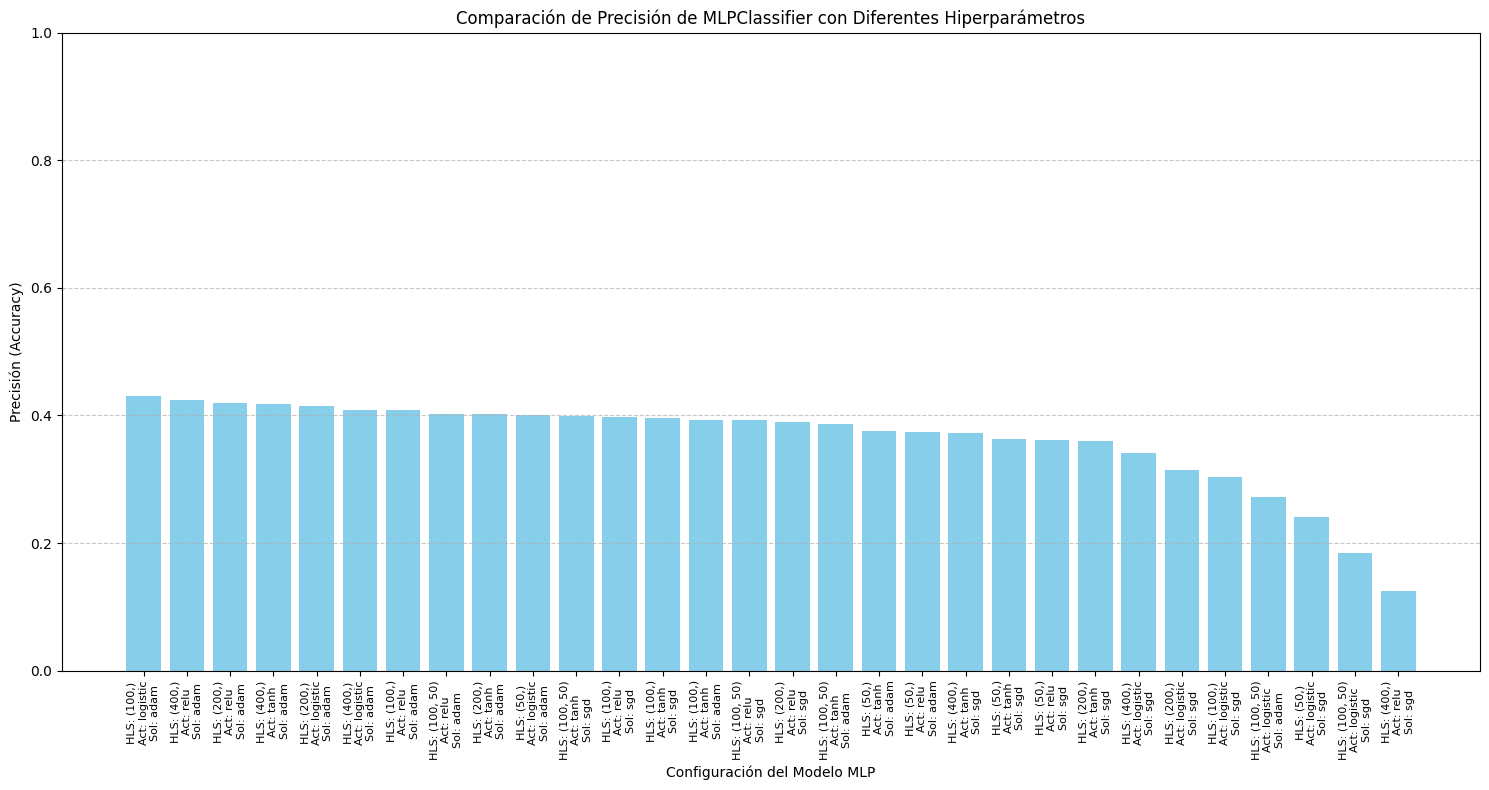


Mejor configuración encontrada:
HLS: (100,)
Act: logistic
Sol: adam
Precisión: 0.4298


In [ ]:
# Convertir resultados a DataFrame para facilitar la visualización
results_df = pd.DataFrame(results)

# Crear una etiqueta combinada para cada configuración
results_df['config'] = results_df.apply(lambda row: f"HLS: {row['hidden_layer_sizes']}\nAct: {row['activation']}\nSol: {row['solver']}", axis=1)

# Ordenar por precisión para una mejor visualización
results_df = results_df.sort_values(by='accuracy', ascending=False)

fig = plt.figure(figsize=(15, 8))
plt.bar(results_df['config'], results_df['accuracy'], color='skyblue')
plt.xlabel('Configuración del Modelo MLP')
plt.ylabel('Precisión (Accuracy)')
plt.title('Comparación de Precisión de MLPClassifier con Diferentes Hiperparámetros')
plt.xticks(rotation=90, fontsize=8) # Rotar etiquetas para que sean legibles
plt.ylim(0, 1) # La precisión va de 0 a 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajustar el diseño para evitar el solapamiento
plt.show()

# Imprimir el mejor resultado
best_result = results_df.iloc[0]
print(f"\nMejor configuración encontrada:\n{best_result['config']}\nPrecisión: {best_result['accuracy']:.4f}")